In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
from features import get_summarized_season
from clustering import group_pca
from sklearn.cluster import KMeans
# from utils import get_mens_regular_season, get_mens_tourney, get_mens_seeeds, get_womens_regular_season, get_womens_tourney, get_womens_seeeds

warnings.filterwarnings("ignore")

data_dir = "/Users/loganheydt/Desktop/Data/GitHub/Kaggle_competitions/March_Machine_Learning_Mania_2026/data"


In [2]:
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

In [3]:
# using the last 20 years of data, change it needed
# cut_off = 2005
cut_off = 1600

regular_results = M_regular_results.loc[M_regular_results['Season'] >= cut_off]
tourney_results = M_tourney_results.loc[M_tourney_results['Season'] >= cut_off]
seeds = M_seeds.loc[M_seeds['Season'] >= cut_off]

# regular_results = W_regular_results.loc[W_regular_results['Season'] >= cut_off]
# tourney_results = W_tourney_results.loc[W_tourney_results['Season'] >= cut_off]
# seeds = W_seeds.loc[W_seeds['Season'] >= cut_off]

In [4]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


In [5]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19


In [6]:
max_day = tourney_results['DayNum'].max()

In [7]:
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [8]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds["division"] = seeds["Seed"].apply(lambda x: x[0])

seeds.head()

,Season,Seed,TeamID,seed,division
0,1985,W01,1207,1,W
1,1985,W02,1210,2,W
2,1985,W03,1228,3,W
3,1985,W04,1260,4,W
4,1985,W05,1374,5,W


In [9]:
champs = tourney_results.loc[tourney_results['DayNum']==max_day]
champs = champs.rename(columns={'WTeamID': 'TeamID'})
champs = champs.merge(seeds, how='left', on=['Season', 'TeamID'])

In [10]:
champs['seed'].value_counts().sort_index()

seed
1    15
2     2
3     3
4     1
7     1
Name: count, dtype: int64

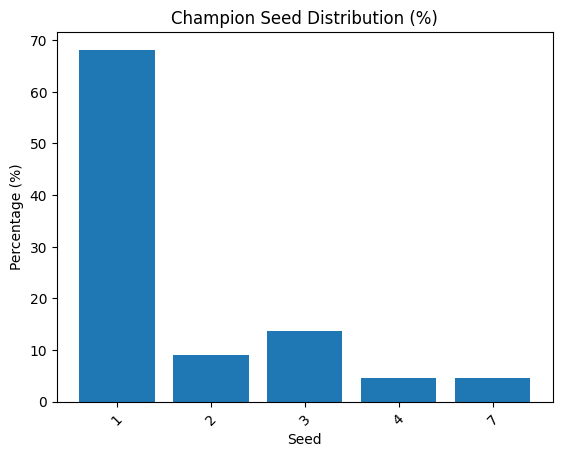

In [11]:
seed_pct = (
    champs['seed']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(seed_pct.index.astype(str), seed_pct.values)

plt.xlabel("Seed")
plt.ylabel("Percentage (%)")
plt.title("Champion Seed Distribution (%)")
plt.xticks(rotation=45)

plt.show()

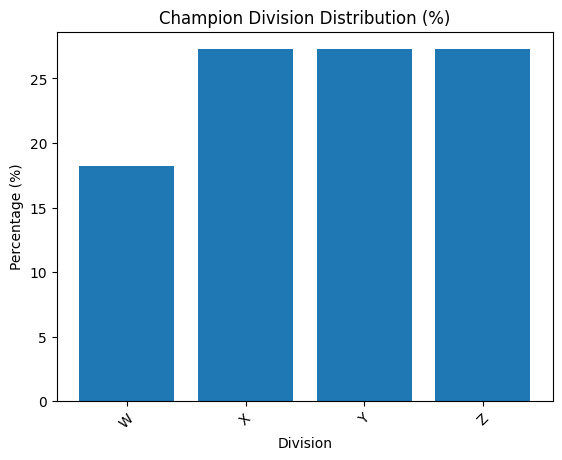

In [12]:
div_pct = (
    champs['division']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(div_pct.index.astype(str), div_pct.values)

plt.xlabel("Division")
plt.ylabel("Percentage (%)")
plt.title("Champion Division Distribution (%)")
plt.xticks(rotation=45)

plt.show()

In [13]:
tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Wseed'})

tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Lseed'})

In [14]:
tourney_results['seed_dif'] = tourney_results['Wseed'] - tourney_results['Lseed']
tourney_results['point_dif'] = tourney_results['WScore'] - tourney_results['LScore']

In [15]:
tourney_results[['seed_dif', 'point_dif']].corr()

,seed_dif,point_dif
seed_dif,1.000000,-0.394906
point_dif,-0.394906,1.000000


In [16]:
mens_season_stats = get_summarized_season(df=M_regular_results, seeds=M_seeds)

In [17]:
mens_season_stats.columns

Index(['games', 'is_win', 'possessions_avg', 'Score', 'FGM', 'FGA', 'FGM3',
       'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
       'opp_Score', 'opp_FGM', 'opp_FGA', 'opp_FGM3', 'opp_FGA3', 'opp_FTM',
       'opp_FTA', 'opp_OR', 'opp_DR', 'opp_Ast', 'opp_TO', 'opp_Stl',
       'opp_Blk', 'opp_PF', 'win_pct', 'fg_pct', 'fg3_pct', 'ft_pct',
       'opp_fg_pct', 'opp_fg3_pct', 'opp_ft_pct', 'off_rating', 'def_rating',
       'net_rating', 'efg', 'opp_efg', 'tov_rate', 'opp_tov_rate', 'ft_rate',
       'opp_ft_rate', 'orb_margin_pg', 'drb_margin_pg', 'pos_per_game',
       'seed'],
      dtype='object')

## PCA

In [18]:
reduced_df, pca_group_dict, fitted_objects = group_pca(
    df=mens_season_stats
)

In [19]:
# Elbow method
inertias = []
mapping1 = {}
K = range(1,10)

for k in K:
    model = KMeans(k, random_state=7).fit(reduced_df.values)
    labels = model.labels_
    centers = model.cluster_centers_

    inertias.append(model.inertia_)

    mapping1[k] = inertias[-1]

Inertia values:
1 : 242554.61743716378
2 : 184819.07404530633
3 : 159251.6943028887
4 : 146243.47497258452
5 : 136140.55270821642
6 : 128377.11908145124
7 : 122428.03871056435
8 : 117691.44423446247
9 : 113904.6824630085


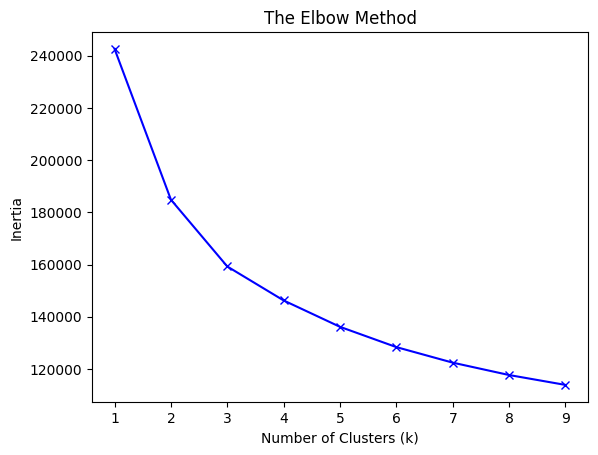

In [20]:
print("Inertia values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [23]:
# def add_team_clusters(df, pca_features, n_clusters=5, random_state=42):
pca_features = reduced_df.values
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(pca_features)
out = mens_season_stats.copy()
out["team_cluster"] = cluster_labels
 

In [24]:
out

games  is_win  possessions_avg  Score  FGM   FGA  FGM3  FGA3  \
Season TeamID                                                                 
2003   1102       28      12        1541.2750   1603  536  1114   219   583   
       1103       27      13        1914.3000   2127  733  1508   147   434   
       1104       28      17        1868.1750   1940  673  1601   178   556   
       1105       26       7        1993.6875   1866  634  1602   197   540   
       1106       28      13        1896.0500   1781  656  1548   171   494   
...              ...     ...              ...    ...  ...   ...   ...   ...   
2026   1477       22       7        1557.8625   1499  521  1247   181   570   
       1478       22      10        1536.1375   1588  536  1199   173   494   
       1479       21       9        1370.5375   1363  523  1189   118   369   
       1480       20       8        1442.6375   1477  536  1243   143   414   
       1481       19       7        1215.3500   1135  413   973   113   379   

               FTM  FTA  ...   opp_efg  tov_rate  opp_tov_rate   ft_rate  \
Season TeamID            ...                                               
2003   1102    312  479  ...  0.510522  0.207620      0.235519  0.429982   
       1103    514  698  ...  0.545809  0.178133      0.216267  0.462865   
       1104    416  586  ...  0.476190  0.199125      0.207689  0.366021   
       1105    401  568  ...  0.511089  0.243268      0.245274  0.354557   
       1106    298  461  ...  0.451505  0.251576      0.222568  0.297804   
...            ...  ...  ...       ...       ...           ...       ...   
2026   1477    276  400  ...  0.537955  0.186794      0.164328  0.320770   
       1478    343  478  ...  0.495472  0.176416      0.142565  0.398666   
       1479    199  280  ...  0.494968  0.139361      0.183140  0.235492   
       1480    262  367  ...  0.552345  0.154578      0.140021  0.295253   
       1481    196  285  ...  0.527027  0.176904      0.163739  0.292909   

               opp_ft_rate  orb_margin_pg  drb_margin_pg  pos_per_game  seed  \
Season TeamID                                                                  
2003   1102       0.453704       0.303109       0.455072     55.045536   NaN   
       1103       0.388564       0.448217       0.474846     70.900000   NaN   
       1104       0.308880       0.554745       0.513804     66.720536  10.0   
       1105       0.415525       0.505764       0.466977     76.680288   NaN   
       1106       0.411371       0.520424       0.516229     67.716071   NaN   
...                    ...            ...            ...           ...   ...   
2026   1477       0.364833       0.441253       0.467773     70.811932   NaN   
       1478       0.340377       0.420366       0.504306     69.824432   NaN   
       1479       0.418115       0.459459       0.470334     65.263690   NaN   
       1480       0.370184       0.556787       0.475570     72.131875   NaN   
       1481       0.277027       0.443182       0.469965     63.965789   NaN   

               team_cluster  
Season TeamID                
2003   1102               1  
       1103               3  
       1104               4  
       1105               2  
       1106               4  
...                     ...  
2026   1477               1  
       1478               1  
       1479               1  
       1480               1  
       1481               1  

[8346 rows x 52 columns]

In [ ]:
# NEXT STEPS:
# VERIFY get_summarized_season WORKS
# RE-RUN PCA EXPLORATION
# RE-RUN CLUSTERING EXPLORATION

In [68]:
# 1. Build season stats -  DONE
# 2. Create efficiency metrics - DONE
# 3. Run PCA - Questionable?
# 4. Cluster teams - Questionable?
# 5. Build matchup dataset
# 6. Train XGBoost
# 7. Calibrate probabilities

# Ideas
### Compare avg regular season stats (scoring, defense, differentials)
### Understand how each team played against other types of team
###    - Did they play well against good defenses? 
###    - Are they more prone to lose if the other team is known for lots of offensive boards?